In [1]:
# Step 1: Import libraries
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
# Step 2: Set dataset paths
import os
import shutil
from sklearn.model_selection import train_test_split


In [3]:
# Path to the dataset folder
dataset_dir = '/Users/shirishkarmacharya/Desktop/assignment/NN/dog/Images'

# Paths to save train, test, and validation sets
output_dir = '/Users/shirishkarmacharya/Desktop/assignment/NN/dog'
train_dir = os.path.join(output_dir, 'train')
test_dir = os.path.join(output_dir, 'test')
val_dir = os.path.join(output_dir, 'val')

# Create the directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)



In [4]:
# Split ratio
test_size = 0.2  # 20% for testing
val_size = 0.1   # 10% for validation (from the remaining 80%)

for breed in os.listdir(dataset_dir):
    breed_path = os.path.join(dataset_dir, breed)
    if not os.path.isdir(breed_path):
        continue

    # Get all image file paths for the breed
    images = [os.path.join(breed_path, img) for img in os.listdir(breed_path) if img.endswith(('.jpg', '.png', '.jpeg'))]

    # Split into train+val and test
    train_val_imgs, test_imgs = train_test_split(images, test_size=test_size, random_state=42)

    # Further split train+val into train and val
    train_imgs, val_imgs = train_test_split(train_val_imgs, test_size=val_size / (1 - test_size), random_state=42)

    # Copy files to their respective folders
    for img in train_imgs:
        dest = os.path.join(train_dir, breed)
        os.makedirs(dest, exist_ok=True)
        shutil.copy(img, dest)

    for img in val_imgs:
        dest = os.path.join(val_dir, breed)
        os.makedirs(dest, exist_ok=True)
        shutil.copy(img, dest)

    for img in test_imgs:
        dest = os.path.join(test_dir, breed)
        os.makedirs(dest, exist_ok=True)
        shutil.copy(img, dest)

    print(f"Processed {breed}: {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test.")


Processed n02092002-Scottish_deerhound: 161 train, 24 val, 47 test.
Processed n02091244-Ibizan_hound: 131 train, 19 val, 38 test.
Processed n02091831-Saluki: 140 train, 20 val, 40 test.
Processed n02090622-borzoi: 105 train, 15 val, 31 test.
Processed n02093256-Staffordshire_bullterrier: 108 train, 16 val, 31 test.
Processed n02089973-English_foxhound: 109 train, 16 val, 32 test.
Processed n02085782-Japanese_spaniel: 129 train, 19 val, 37 test.
Processed n02086079-Pekinese: 104 train, 15 val, 30 test.
Processed n02085936-Maltese_dog: 175 train, 26 val, 51 test.
Processed n02086646-Blenheim_spaniel: 131 train, 19 val, 38 test.
Processed n02088238-basset: 122 train, 18 val, 35 test.
Processed n02085620-Chihuahua: 105 train, 16 val, 31 test.
Processed n02090379-redbone: 103 train, 15 val, 30 test.
Processed n02090721-Irish_wolfhound: 152 train, 22 val, 44 test.
Processed n02088632-bluetick: 119 train, 17 val, 35 test.
Processed n02091467-Norwegian_elkhound: 136 train, 20 val, 40 test.
Pro

In [5]:
# Step 3: Preprocess the data
img_width = 180  # Resize all images to 128x128
img_height = 180

In [7]:
data_train = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    shuffle = True,
    image_size = (img_width,img_height),
    batch_size = 32,
    validation_split = False)

Found 5448 files belonging to 30 classes.


In [8]:
data_test = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle = True,
    image_size = (img_width,img_height),
    batch_size = 32,
    validation_split = False)

Found 1102 files belonging to 30 classes.


In [9]:
data_dog = data_train.class_names

In [10]:
data_dog

['n02085620-Chihuahua',
 'n02085782-Japanese_spaniel',
 'n02085936-Maltese_dog',
 'n02086079-Pekinese',
 'n02086240-Shih-Tzu',
 'n02086646-Blenheim_spaniel',
 'n02086910-papillon',
 'n02087046-toy_terrier',
 'n02087394-Rhodesian_ridgeback',
 'n02088094-Afghan_hound',
 'n02088238-basset',
 'n02088364-beagle',
 'n02088466-bloodhound',
 'n02088632-bluetick',
 'n02089078-black-and-tan_coonhound',
 'n02089867-Walker_hound',
 'n02089973-English_foxhound',
 'n02090379-redbone',
 'n02090622-borzoi',
 'n02090721-Irish_wolfhound',
 'n02091032-Italian_greyhound',
 'n02091134-whippet',
 'n02091244-Ibizan_hound',
 'n02091467-Norwegian_elkhound',
 'n02091635-otterhound',
 'n02091831-Saluki',
 'n02092002-Scottish_deerhound',
 'n02092339-Weimaraner',
 'n02093256-Staffordshire_bullterrier',
 'n02093428-American_Staffordshire_terrier']

In [11]:
data_val = tf.keras.utils.image_dataset_from_directory(
    val_dir,                                                   
    image_size=(img_height,img_width),
    batch_size=32,                                                   
    shuffle=False,                                  
    validation_split=False)

Found 556 files belonging to 30 classes.


2024-11-18 11:06:21.650025: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


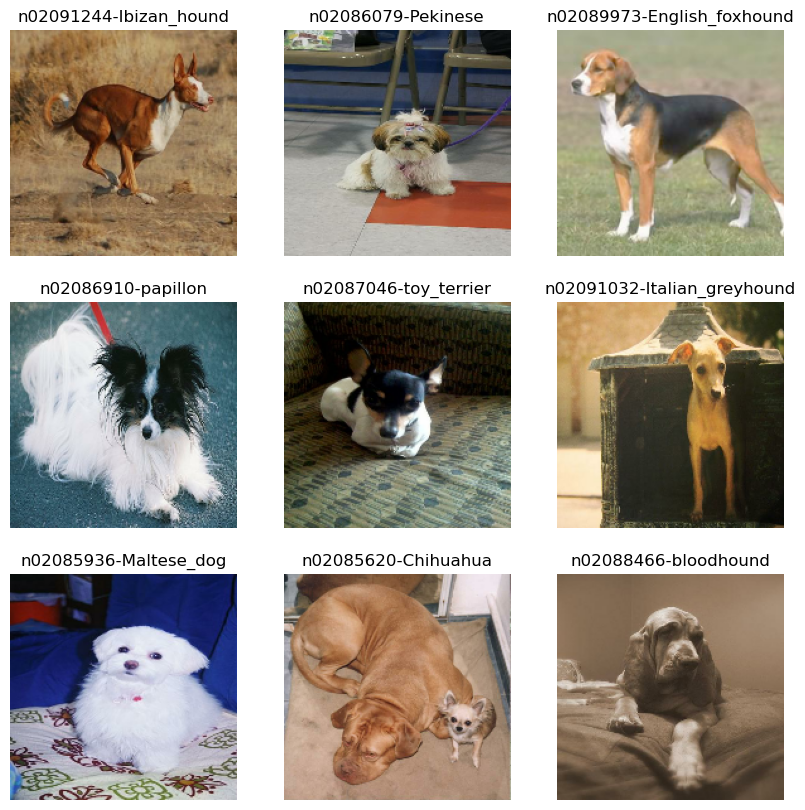

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_dog[labels[i]])
        plt.axis('off')

In [13]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [15]:
model = Sequential()

In [16]:
model.add(Conv2D(32,kernel_size=(3,3), padding='valid', activation='relu', input_shape=(28,28,1) ))
model.add(Conv2D(32,kernel_size=(3,3), padding='valid',activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3), padding='valid',activation='relu'))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='relu'))

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,002,698 (7.64 MB)

 Trainable params: 2,002,698 (7.64 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#with Padding
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3), padding='same', activation='relu', input_shape=(28,28,1) ))
model.add(Conv2D(16,kernel_size=(3,3), padding='same',activation='relu'))
model.add(Conv2D(8,kernel_size=(3,3), padding='same',activation='relu'))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='relu'))

In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 810,338 (3.09 MB)

 Trainable params: 810,338 (3.09 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#Stride is used for decreasing the feature map size
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3), padding='same', strides = (2,2), activation='relu', input_shape=(28,28,1) ))
model.add(Conv2D(32,kernel_size=(3,3), padding='same',strides = (2,2),activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3), padding='same',strides = (2,2),activation='relu'))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='relu'))

In [21]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,770 (335.04 KB)

 Trainable params: 85,770 (335.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [23]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras import layers

model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_dog))  # Ensure 'data_cat' is defined elsewhere
])


In [24]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [25]:
epochs_size = 10
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 78s 450ms/step - accuracy: 0.0492 - loss: 3.5874 - val_accuracy: 0.1169 - val_loss: 3.1819
Epoch 2/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 88s 514ms/step - accuracy: 0.1393 - loss: 3.1029 - val_accuracy: 0.2932 - val_loss: 2.6654
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 72s 420ms/step - accuracy: 0.2636 - loss: 2.6590 - val_accuracy: 0.4083 - val_loss: 2.1546
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 74s 434ms/step - accuracy: 0.4130 - loss: 2.0834 - val_accuracy: 0.5576 - val_loss: 1.5591
Epoch 5/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 72s 420ms/step - accuracy: 0.5929 - loss: 1.4331 - val_accuracy: 0.6709 - val_loss: 1.1649
Epoch 6/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 73s 427ms/step - accuracy: 0.7150 - loss: 0.9662 - val_accuracy: 0.7320 - val_loss: 0.8572
Epoch 7/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 72s 418ms/step - accuracy: 0.7972 - loss: 0.6940 - val_accuracy: 0.8363 - val_loss: 0.6220
Epoch 8/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 73s 425ms/step - accuracy: 0.8521 - loss: 0

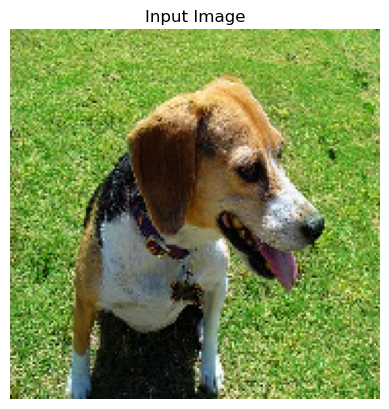

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted class: n02088364-beagle


In [76]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to your image
image_path = '/Users/shirishkarmacharya/Desktop/assignment/NN/Images/n02088364-beagle/n02088364_427.jpg'

# Load the image
img = image.load_img(image_path, target_size=(180, 180))
plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()

# Preprocess the image
img_array = image.img_to_array(img)  # Convert image to array
img_array = img_array / 255.0        # Normalize the image
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Predict the class
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions, axis=1)

# Get the class labels
class_labels = data_train.class_names
print(f"Predicted class: {class_labels[predicted_class[0]]}")


In [26]:
history_dict = history.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

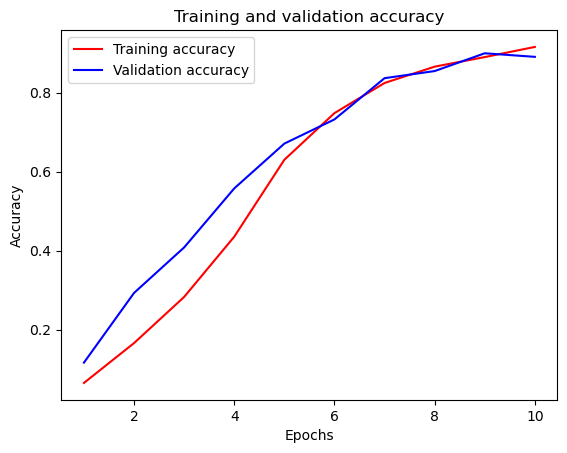

In [27]:
import matplotlib.pyplot as plt
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [28]:
# Step 9: Predictions and metrics
y_true = []
y_pred = []

for images, labels in data_test:
    preds = tf.argmax(model.predict(images), axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━

2024-11-18 11:20:05.836297: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [29]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
# Calculate precision, recall, and F1-score
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Precision: 0.9345256339110728
Recall: 0.9292196007259528
F1 Score: 0.929043591787722


In [30]:
print(classification_report(y_true, y_pred, target_names=data_dog))

                                          precision    recall  f1-score   support

                     n02085620-Chihuahua       0.82      1.00      0.90        31
              n02085782-Japanese_spaniel       1.00      0.78      0.88        37
                   n02085936-Maltese_dog       0.91      0.98      0.94        51
                      n02086079-Pekinese       0.88      0.97      0.92        30
                      n02086240-Shih-Tzu       0.86      0.98      0.91        43
              n02086646-Blenheim_spaniel       1.00      0.84      0.91        38
                      n02086910-papillon       0.86      0.95      0.90        40
                   n02087046-toy_terrier       0.91      0.89      0.90        35
           n02087394-Rhodesian_ridgeback       1.00      0.94      0.97        35
                  n02088094-Afghan_hound       0.94      0.98      0.96        48
                        n02088238-basset       0.95      1.00      0.97        35
               